# Chapter 18: Production Architecture and Capstone

**Level 4: Expert** · ⏱ about 6 hours · Dataset: *EduGraph*

### What you will learn

1. A **reference architecture** for a knowledge-graph application on Stardog, and where every earlier chapter fits in it
2. **Ontology versioning and governance**: release numbers, change classification, and automated checks
3. A **production pipeline**: staging graphs, a SHACL quality gate, atomic promotion, reasoning checks and materialization, with every run recorded
4. **Performance decisions**: connection reuse, caching, materialized vs query-time reasoning, and what clustering adds
5. **Serving**: the EduGraph API with a connection pool, a cache, a GraphRAG `/ask` endpoint and a `/metrics` endpoint
6. **Multi-tenancy**: several schools in one database, and where the isolation really comes from
7. **Monitoring**: a dashboard and alert rules built from the graph's own records

### The capstone

Everything comes together in one system:

**ingestion** (CSV mappings + LLM document extraction) → **SHACL gate** → **reasoning** → **FastAPI** → **GraphRAG chat** → **monitoring dashboard**

### Before you start

- Ollama with `qwen2.5:7b` and `nomic-embed-text` (Chapter 11). LLM answers are cached in `data/edugraph/capstone_llm_cache.json`.
- This chapter creates an environment named `ch18`: graphs under `urn:tutorial:ch18:…`, the reasoning model `EduGraph_ch18`, stored queries `ch18_edugraph_*`, and the API user `ch18_api` with its role. The clean-up at the end removes all of them.

In [1]:
import importlib
import json
import os
import shutil
import sys
import tempfile
import time
from pathlib import Path

TUTORIAL = Path('..').resolve()
for p in (str(TUTORIAL / 'src'), str(TUTORIAL)):
    if p not in sys.path:
        sys.path.insert(0, p)

import matplotlib.pyplot as plt
import pandas as pd
import stardog
from rdflib import Graph, URIRef

from kg import backup, client, extraction, governance, imports, perf, pipeline, security, sparql, validation

pd.set_option('display.max_colwidth', 100)
conn = client.connect()
ENV = pipeline.Environment('ch18', prefix='urn:tutorial:ch18')
EDU = TUTORIAL / 'data' / 'edugraph'
LLM_CACHE = EDU / 'capstone_llm_cache.json'
S023 = URIRef('http://example.org/edu/student/S023')
print('Stardog database:', client.load_settings().database, '| Ollama ready:', extraction.ollama_available())

Stardog database: mysampledb | Ollama ready: True


## 18.1 A reference architecture

A knowledge-graph application has the same layers as any data application. What's special is that **meaning** (the ontology), **quality rules** (SHACL) and **provenance** live in the same graph as the data, so every layer can use them.

```mermaid
flowchart LR
  subgraph Sources
    CSV[SIS exports, CSV]
    MD[Lesson texts]
    TTL[Curriculum, Turtle]
    ONT[Ontology and shapes, in git]
  end
  subgraph Pipeline
    ING[Ingest: SMS2 mappings]
    EXT[Extract and link: LLM]
    GATE{SHACL gate}
    PROM[Promote: one transaction]
    MAT[Reason and materialize]
  end
  subgraph Stardog
    STG[(Staging graphs)]
    LIVE[(Live graphs)]
    MET[(Metrics and provenance)]
  end
  subgraph Services
    API[REST API]
    RAG[GraphRAG chat]
    AG[Agents over MCP]
  end
  CSV --> ING
  TTL --> ING
  MD --> EXT
  ONT --> GATE
  ING --> STG
  EXT --> STG
  STG --> GATE
  GATE -->|no violations| PROM
  PROM --> LIVE
  LIVE --> MAT
  MAT --> LIVE
  LIVE --> API
  LIVE --> RAG
  LIVE --> AG
  PROM -.-> MET
  API -.-> DASH[Monitoring dashboard]
  MET -.-> DASH
```

| Layer | Job | Chapters | In this repository |
|---|---|---|---|
| Sources | Systems of record, documents | 3, 10, 11 | `data/edugraph/` |
| Model | Ontology, rules, shapes | 7, 8, 9, 18 | `ontology/` |
| Ingestion | Mappings, extraction, entity linking | 10, 11 | `ontology/mappings/`, `kg/imports.py`, `kg/extraction.py` |
| Quality | SHACL gate, consistency | 9, 18 | `kg/validation.py`, `kg/pipeline.py` |
| Storage | Named graphs per purpose, staging vs live | 2, 5 | one Stardog database |
| Access | Stored queries, GraphQL, REST | 6, 13 | `src/kg/queries/`, `api/main.py` |
| Intelligence | Reasoning, search, analytics, GraphRAG, agents | 8, 12, 15b, 16, 17 | `kg/llm.py`, `kg/agent.py`, `agents/` |
| Operations | Security, deploy, tests, backups, monitoring | 14, 15, 18 | `ops/`, `tests/`, `kg/backup.py` |

Every name an environment uses is derived from its name, so dev, test and prod (or one tenant per school) can live side by side and be removed cleanly:

In [2]:
layout = [('ontology (reasoning model)', ENV.ontology), ('data shapes', ENV.data_shapes), ('ontology shapes', ENV.ontology_shapes)]
layout += [(f'live: {p}', ENV.live(p)) for p in ENV.PARTS] + [('staging: …', ENV.staging('…'))]
layout += [('materialized inferences', ENV.inferred), ('pipeline runs and metrics', ENV.metrics)]
layout += [('reasoning model name', ENV.schema), ('stored query prefix', ENV.query_prefix), ('API user / role', f'{ENV.user} / {ENV.role}')]
pd.DataFrame(layout, columns=['what', 'name'])

,what,name
0,ontology (reasoning model),urn:tutorial:ch18:ontology
1,data shapes,urn:tutorial:ch18:shapes:data
2,ontology shapes,urn:tutorial:ch18:shapes:ontology
3,live: curriculum,urn:tutorial:ch18:curriculum
4,live: sis:students,urn:tutorial:ch18:sis:students
5,live: sis:enrollments,urn:tutorial:ch18:sis:enrollments
6,live: sis:assessments,urn:tutorial:ch18:sis:assessments
7,live: docs,urn:tutorial:ch18:docs
8,live: review,urn:tutorial:ch18:review
9,staging: …,urn:tutorial:ch18:staging:…


## 18.2 Ontology versioning and governance

An ontology is **code**: applications, queries, shapes and rules depend on it. Treat it like code:

- It lives in **git**, and changes go through review.
- Each release has a **version**: `owl:versionInfo "1.1"`, a version IRI, and `owl:priorVersion` pointing to the release before.
- The previous release is kept (`ontology/versions/edugraph-1.0.ttl`), so every change can be **compared**.
- **Automated checks** run on every change, like unit tests.

Release 1.1 (`ontology/edugraph.ttl`) adds a `Person` class, a transitive `dependsOn`, two rules (`passed` for a score of 50+, `mastered` for 80+), and deprecates `edu:enrolledIn`. `kg.governance.diff` lists and classifies every change:

In [3]:
PREVIOUS, CURRENT = TUTORIAL / 'ontology' / 'versions' / 'edugraph-1.0.ttl', TUTORIAL / 'ontology' / 'edugraph.ttl'
changes = governance.diff(PREVIOUS, CURRENT)
print(governance.check_version('1.0', '1.1', changes))
changes

{'from': '1.0', 'to': '1.1', 'bump': 'minor', 'needed': 'minor', 'ok': True}


,term,change,kind,detail
0,edu:Person,term added,minor,
1,edu:Student,axiom added,minor,rdfs:subClassOf edu:Person
2,edu:dependsOn,term added,minor,
3,edu:enrolledIn,deprecated,minor,owl:deprecated true
4,edu:mastered,term added,minor,
5,edu:passed,term added,minor,
6,edu:requires,axiom added,minor,rdfs:subPropertyOf edu:dependsOn
7,rule,rule added,minor,Passed: an assessment score of 50 or more
8,rule,rule added,minor,Mastered: an assessment score of 80 or more
9,<http://example.org/edu/ontology>,documentation added,patch,owl:priorVersion <http://example.org/edu/ontology/1.0>


The classification follows **semantic versioning**, as for an API:

| Kind | Examples | Effect on existing data and queries | Version |
|---|---|---|---|
| **breaking** | term or rule removed; new domain, range or disjointness on an existing term | may lose meaning, be reclassified, or become inconsistent | major (2.0) |
| **minor** | new terms, rules, superclasses; deprecations | keep working; new inferences appear | minor (1.1) |
| **patch** | labels, comments, version info | none | none needed |

Adding `rdfs:subClassOf edu:Person` to `Student` is minor: it only **adds** inferences. Adding an `rdfs:domain` is not, because with reasoning it **reclassifies** data. Here's a draft 1.2 that looks harmless:

In [4]:
draft = Graph().parse(CURRENT)
EDU_NS = 'http://example.org/edu#'
draft.remove((URIRef(EDU_NS + 'mastered'), None, None))                      # "nobody uses it yet"
draft.add((URIRef(EDU_NS + 'score'), URIRef('http://www.w3.org/2000/01/rdf-schema#domain'), URIRef(EDU_NS + 'Assessment')))
draft_changes = governance.diff(CURRENT, draft)
print(governance.check_version('1.1', '1.2', draft_changes))
draft_changes[draft_changes.kind == 'breaking']

{'from': '1.1', 'to': '1.2', 'bump': 'minor', 'needed': 'major', 'ok': False}


,term,change,kind,detail
0,edu:mastered,term removed,breaking,data and queries using it lose their meaning
1,edu:score,axiom added,breaking,rdfs:domain edu:Assessment


Both changes are **breaking**, and the check refuses a minor version:

- Removing `mastered` breaks every query and rule that uses it, and a rule still derives it.
- The new domain says "anything with a score is an Assessment". But `edu:score` is also used for link similarities (Chapter 11): with reasoning, every link would silently **become an Assessment** and show up in student statistics.

A reviewer might miss both. The check doesn't.

**Governance shapes.** Some rules are about *how* the ontology is written: every term has a label and a comment, every relationship a range, the header a version. They're SHACL shapes over the ontology itself (`ontology/ontology_shapes.ttl`), and the pipeline's first stage runs them. A term added in a hurry fails:

In [5]:
LINT, LINT_SHAPES = f'{ENV.prefix}:lint:ontology', f'{ENV.prefix}:lint:shapes'
with client.transaction(conn):
    for g in (LINT, LINT_SHAPES):
        conn.clear(graph_uri=g)
    conn.add(stardog.content.File(str(TUTORIAL / 'ontology' / 'ontology_shapes.ttl')), graph_uri=LINT_SHAPES)
    conn.add(stardog.content.File(str(CURRENT)), graph_uri=LINT)
print('release 1.1:', validation.validate(conn, LINT_SHAPES, [LINT]).summary())

with client.transaction(conn):
    conn.update(f'''PREFIX edu: <http://example.org/edu#> PREFIX owl: <http://www.w3.org/2002/07/owl#>
                    INSERT DATA {{ GRAPH <{LINT}> {{ edu:likes a owl:ObjectProperty }} }}''')
report = validation.validate(conn, LINT_SHAPES, [LINT])
print('with a quick addition:', report.summary())
report.results[['severity', 'focus', 'message']]

release 1.1: 0 violation(s), 0 warning(s), 0 info(s)


with a quick addition: 2 violation(s), 1 warning(s), 0 info(s)


,severity,focus,message
0,Violation,http://example.org/edu#likes,Every class and property needs a label.
1,Violation,http://example.org/edu#likes,A relationship needs a range: what kind of thing it points to.
2,Warning,http://example.org/edu#likes,Every class and property should be documented (rdfs:comment).


## 18.3 The capstone pipeline

`kg.pipeline` turns the earlier chapters into one repeatable process. Each **stage** is a method; `run()` times them, stops at the first failed **gate**, and records the run in the metrics graph.

| # | Stage | What it does | Gate? |
|---|---|---|---|
| 1 | `ontology` | Lint the ontology (18.2), load it, register it as the reasoning model | ✅ governance shapes |
| 2 | `ingest` | Curriculum file + SIS CSVs through SMS2 mappings (Ch 10) into **staging** graphs | |
| 3 | `documents` | Extract concepts from the lessons with the LLM and link them to topics (Ch 11). Accepted links become facts; uncertain ones go to a **review** graph | |
| 4 | `validate` | SHACL data shapes (`ontology/edugraph_data_shapes.ttl`) over **all** staged data together | ✅ violations stop the run |
| 5 | `promote` | Copy every staged graph over its live graph **in one transaction** | |
| 6 | `reasoning` | Consistency of the live data with the ontology; do the rules infer anything? | ✅ inconsistency |
| 7 | `materialize` | Store `dependsOn`, `passed` and `mastered`, so applications can query without reasoning | |
| 8 | `publish` | Stored queries, and a least-privilege API user (Ch 13-14) | |
| 9 | `smoke_test` | Run the API's key queries **as the API user** | ✅ no results |

Why **staging**? Readers never see a half-loaded or invalid batch: the live graphs change only at promotion, all at once. If the gate fails, the live graphs keep yesterday's data, and the rejected batch stays in staging for inspection.

In [6]:
API_PASSWORD = security.new_password()
run1 = pipeline.Pipeline(conn, ENV, api_password=API_PASSWORD).run()
print()
print('status:', run1['status'])
pd.Series(run1['graph sizes'], name='triples')

✅ ontology        6.0s  {'version': '1.1', 'triples': 151, 'warnings': 0}


✅ ingest         16.3s  {'curriculum': 141, 'students': 280, 'enrollments': 385, 'assessments': 1700}


✅ documents      48.5s  {'documents': 6, 'accepted': 14, 'review': 53, 'new concepts': 3}


✅ validate        0.3s  {'violations': 0, 'warnings': 0}


✅ promote         2.5s  {'graphs promoted': 6}


...

✅ materialize     1.9s  {'triples': 409}


✅ publish        17.4s  {'stored queries': 9, 'api user': 'ch18_api'}


✅ smoke_test      1.7s  {'topics': 21, 'ready topics for S023': 4}



status: ok


urn:tutorial:ch18:curriculum          141
urn:tutorial:ch18:sis:students        280
urn:tutorial:ch18:sis:enrollments     385
urn:tutorial:ch18:sis:assessments    1700
urn:tutorial:ch18:docs                 32
urn:tutorial:ch18:inferred            409
Name: triples, dtype: int64

The `documents` stage is the slow one (LLM extraction and embeddings); the rest takes seconds. Most extracted links weren't certain enough to become facts. They wait in the **review** graph for a person, as in Chapter 11:

In [7]:
sparql.run_query(conn, '''PREFIX edu: <http://example.org/edu#>
SELECT ?method (COUNT(*) AS ?links) (SAMPLE(?m) AS ?example)
{ ?l a edu:TopicLink ; edu:method ?method ; edu:mention ?m } GROUP BY ?method''', graphs=ENV.live('review'))

,method,links,example
0,llm,53,roc curve


### The gate at work

Tomorrow's SIS export contains three bad rows: a score of 140, a topic that doesn't exist, and a student nobody knows. We run the ingest, validate and promote stages on it:

In [8]:
bad_dir = Path(tempfile.mkdtemp(prefix='edugraph-bad-'))
shutil.copytree(EDU / 'sis', bad_dir / 'sis')
shutil.copy(EDU / 'curriculum.ttl', bad_dir / 'curriculum.ttl')
with open(bad_dir / 'sis' / 'assessments.csv', 'a', encoding='utf-8') as f:
    f.write('A9001,S023,regression,140,2025-06-01\n')
    f.write('A9002,S023,quantum-computing,70,2025-06-01\n')
    f.write('A9003,S999,statistics,55,2025-06-01\n')

run2 = pipeline.Pipeline(conn, ENV, data_dir=bad_dir).run(stages=('ingest', 'validate', 'promote'))
report = run2['report']
report.results[report.results.severity == 'Violation'][['focus', 'path', 'value', 'message']]

✅ ingest         16.7s  {'curriculum': 141, 'students': 280, 'enrollments': 385, 'assessments': 1715}


⛔ validate        0.3s  {'blocked': 'validate: 3 violations: nothing was promoted'}


,focus,path,value,message
0,http://example.org/edu/assessment/A9001,score,140,A score must be one integer from 0 to 100.
1,http://example.org/edu/assessment/A9002,topic,http://example.org/edu/topic/quantum-computing,An assessment is about exactly one known topic.
2,http://example.org/edu/assessment/A9003,student,http://example.org/edu/student/S999,An assessment belongs to exactly one known student.


In [9]:
live = sparql.run_query(conn, 'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(*) AS ?n) { ?a a edu:Assessment }',
                        graphs=ENV.live('sis:assessments')).n.iloc[0]
staged = sparql.run_query(conn, 'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(*) AS ?n) { ?a a edu:Assessment }',
                          graphs=ENV.staging('sis:assessments')).n.iloc[0]
print(f'live assessments: {live} (unchanged) | quarantined in staging: {staged}')
shutil.rmtree(bad_dir)

live assessments: 340 (unchanged) | quarantined in staging: 343


Promotion never ran, so the API keeps serving yesterday's valid data. In production the pipeline exits with an error (see `ops/edugraph_pipeline.py`), the scheduler alerts someone, and the report says exactly which rows to fix at the source.

Every run, good or blocked, is in the metrics graph:

In [10]:
history = pipeline.history(conn, ENV)
history.groupby(['run', 'status'], sort=False).agg(started=('started', 'first'), stages=('stage', ' → '.join),
                                                    seconds=('seconds', 'sum')).reset_index(level='status')

,status,started,stages,seconds
run,,,,
urn:tutorial:ch18/run/20260928T045022691628,ok,2026-09-28 04:50:22.691662+00:00,ontology → ingest → documents → validate → promote → reasoning → materialize → publish → smoke_test,95.54
urn:tutorial:ch18/run/20260928T045201499025,blocked at validate,2026-09-28 04:52:01.499177+00:00,ingest → validate,16.98


### Governance on the live data

Two more checks, now that data is loaded. Does the data use **vocabulary the ontology doesn't define** (typos, drift, forgotten terms)? We include the review graph:

In [11]:
governance.undeclared_terms(conn, ENV.ontology, ENV.data_graphs + [ENV.live('review')])

,term,usage,triples
0,http://example.org/edu#TopicLink,class,53
1,http://example.org/edu#document,property,53
2,http://example.org/edu#mention,property,53
3,http://example.org/edu#method,property,53
4,http://example.org/edu#role,property,53
5,http://example.org/edu#status,property,53


A real finding: the pipeline's own **review vocabulary** (`TopicLink`, `mention`, `method`, …) was never added to the ontology. Nothing breaks today, but no one can look up what `edu:method` means, and SHACL can't check it. That's the next ontology release (exercise 1).

And which **deprecated** terms are still in use, in the data and in the stored queries?

In [12]:
governance.deprecated_usage(conn, ENV.ontology, ENV.data_graphs, query_folder='edugraph')

,term,data triples,queries
0,http://example.org/edu#enrolledIn,77,"edugraph/course_performance, edugraph/prerequisite_gaps, edugraph/student_profile"


Deprecation is a **migration plan**, not a deletion: three stored queries (the API's own!) must switch to `edu:Enrollment`, and the SIS mapping must stop writing `edu:enrolledIn`. Only when this table shows zeros can release 2.0 remove the term. That's a breaking change made safe by doing it in two steps.

## 18.4 Performance decisions

### Connections and caching

Every request to Stardog Cloud crosses the internet. Opening a **new connection** means a TLS handshake and a login first. We compare three ways to run the same stored query:

In [13]:
TOPICS = ENV.query_prefix + 'topics'

def timed(fn, n=5):
    times = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); times.append((time.perf_counter() - t0) * 1000)
    return round(pd.Series(times).median())

def new_connection():
    with client.connect() as c:
        sparql.run_stored(c, TOPICS, graphs=ENV.data_graphs)

reused = client.connect()
cache = {}
def cached():
    if TOPICS not in cache:
        cache[TOPICS] = sparql.run_stored(reused, TOPICS, graphs=ENV.data_graphs)
    return cache[TOPICS]

pd.DataFrame({'median ms': {'new connection per query': timed(new_connection),
                            'reused connection': timed(lambda: sparql.run_stored(reused, TOPICS, graphs=ENV.data_graphs)),
                            'result cache': timed(cached)}})

,median ms
new connection per query,1438
reused connection,256
result cache,0


Reusing connections saves more than any query tuning in Chapter 15 could. So the API (18.5) keeps a **pool** of open connections. Connections aren't thread-safe, so each request borrows one and returns it afterwards; one that failed is thrown away.

A **result cache** is faster still, but serves **stale** data until it expires. Two rules make it safe:

- Cache only what may be a little old (topics, courses: yes; a student's own new score: think twice).
- Tie the expiry to how data changes. Here data only changes at **promotion**, so the pipeline could clear the cache then, and results could otherwise be cached for hours.

### Materialized vs query-time reasoning

"Which topics is S023 ready for?" needs `edu:passed`. Two ways to get it:

- **Query-time reasoning**: the rules derive `passed` from the scores for each query (Chapter 8). Always current, no extra storage.
- **Materialized**: the pipeline stored the same facts in the `inferred` graph (stage 7). Plain queries, but only correct until the data changes.

In [14]:
ready = sparql.load_query('edugraph/ready_topics').replace('?student', f'<{S023}>')
depends = '''PREFIX edu: <http://example.org/edu#>
SELECT ?name { <http://example.org/edu/topic/neural-networks> edu:dependsOn ?t . ?t edu:name ?name }'''
LIVE = [ENV.live(p) for p in ENV.PARTS if p != 'review']

rows = {}
for label, query in (('ready topics for S023', ready), ('everything neural networks depends on', depends)):
    rows[(label, 'query-time reasoning')] = perf.bench(conn, query, LIVE, runs=3, reasoning=True, schema=ENV.schema)
    rows[(label, 'materialized')] = perf.bench(conn, query, ENV.data_graphs, runs=3)
pd.DataFrame(rows).T

median_s  min_s  \
ready topics for S023                 query-time reasoning     0.273  0.272   
                                      materialized             0.269  0.268   
everything neural networks depends on query-time reasoning     0.268  0.268   
                                      materialized             0.267  0.266   

                                                            rows  
ready topics for S023                 query-time reasoning   4.0  
                                      materialized           4.0  
everything neural networks depends on query-time reasoning  13.0  
                                      materialized          13.0

Same rows either way: the pipeline materialized exactly what the rules infer. And here, **no measurable difference** in time: each query takes about as long as the network round trip to Stardog Cloud (≈ 0.25 s), and the reasoning work on 2,000 triples disappears in it. Measure before you optimize.

So why materialize at all? Speed matters at scale (reasoning cost grows with the data, network time doesn't), but the everyday reasons are others: queries work **without reasoning**, so any client can use them (GraphQL, BI tools, the least-privilege API user, other databases the data is exported to); results are **predictable** and **cacheable**; and a **backup** contains the inferences. The price is freshness: the facts are only as current as the last pipeline run. The usual production answer is **both**:

| Approach | Freshness | Speed | Use for |
|---|---|---|---|
| **Query-time reasoning** | always current | slower, varies with the data | analysts, ad-hoc questions, rarely used inferences |
| **Materialized** in the pipeline | as of the last run | fast, predictable, cacheable | hot API paths, dashboards |
| **Virtual graphs** (Ch 10) | live from the source | depends on the source system | fast-changing data, data you may not copy |
| **Imported** (materialized source data) | as of the last import | fast, can be validated and reasoned over | most analytical data (our SIS) |

### Clustering and Stardog's caches

Two features of self-managed or dedicated Stardog deployments, which this Cloud database doesn't offer:

In [15]:
with client.admin() as admin:
    for name, call in (('cluster status', admin.cluster_status), ('cache targets', admin.cache_targets)):
        try:
            print(f'{name:15}', call())
        except stardog.exceptions.StardogException as e:
            print(f'{name:15} {e.http_code}: not available on this server')

cluster status  404: not available on this server


cache targets   []


- A **Stardog cluster** (Enterprise) keeps full copies of every database on several nodes, with a coordinator and consensus. It gives **high availability** (a node can fail) and **read scaling** (queries spread over nodes). Writes still go through every node, so it doesn't make writes faster. This server is a single node (`404`), so our availability relies on backups (18.8) and Stardog Cloud's own operations.
- **Cache targets** let Stardog keep copies of **virtual graphs** or remote data on dedicated cache nodes, refreshed on a schedule. It's the "materialize, but managed by Stardog" option in the table above. None are configured here.

## 18.5 Serving: the API

The Chapter 13 API has grown for production (see `api/main.py`):

- a **connection pool** (`EDUGRAPH_POOL_SIZE`, default 4)
- an optional **result cache** (`EDUGRAPH_CACHE_SECONDS`)
- `/students/{id}/ready`, answered from the **materialized** inferences
- `/ask`: **GraphRAG** over the curriculum and lessons (Chapter 16's approach, with EduGraph queries `graphrag_entities.rq` and `graphrag_facts.rq`)
- `/metrics`: requests, errors and latency per route, plus cache and pool figures

We point it at the `ch18` environment. It connects as the **least-privilege** user the pipeline created, and runs in-process with FastAPI's test client:

In [16]:
from fastapi.testclient import TestClient

API_KEY = 'capstone-demo-key'
os.environ.update({'EDUGRAPH_GRAPHS': ','.join(ENV.data_graphs), 'EDUGRAPH_QUERY_PREFIX': ENV.query_prefix,
                   'EDUGRAPH_STARDOG_USER': ENV.user, 'EDUGRAPH_STARDOG_PASSWORD': API_PASSWORD,
                   'EDUGRAPH_API_KEY': API_KEY, 'EDUGRAPH_CACHE_SECONDS': '60', 'EDUGRAPH_LLM_CACHE': str(LLM_CACHE)})
import api.main
api_module = importlib.reload(api.main)                   # read the environment again
api = TestClient(api_module.app)
H = {'X-API-Key': API_KEY}

print(api.get('/health').json())
print(api.get('/students/S023', headers=H).json())
pd.DataFrame(api.get('/students/S023/ready', headers=H).json()['ready'])

{'status': 'ok', 'database': 'mysampledb', 'triples': 8388}


{'id': 'S023', 'name': 'Aarav Sharma', 'city': 'Sao Paulo', 'year': 2, 'courses': 'MA120, ML201', 'assessments': 9, 'avg_score': 60.0}


,id,name,level
0,python-basics,Python basics,1
1,sql-basics,SQL basics,1
2,statistics,Statistics,2
3,classification,Classification,3


Read it against S023's scores (Chapter 17): they passed Probability, so **Statistics** is open (their 33 means they haven't passed it yet); they passed Linear regression, so **Classification** is open; Python basics and SQL basics have no prerequisites and S023 never took them. Topics they already passed aren't listed.

The API holds only the `ch18_api` account, which can read and nothing else (Chapter 14).

### GraphRAG chat

`/ask` retrieves the closest topics and lessons by embedding, collects their facts from the graph (prerequisites, courses, lessons, and the materialized `dependsOn`), and lets the LLM answer **only from those facts**. Two settings came from trying it out:

- **Instructions for this domain** (`ASK_INSTRUCTIONS` in `api/main.py`): the generic Chapter 16 prompt made the model echo the fact rows back. Saying how to read a fact ("subject | relation | value, in that direction"), with an example, and "don't list facts" fixed it.
- **A retrieval margin**: only entities scoring within 0.1 of the best match. Without it, loosely related entities (the *Algebra refresher* scored about 0.5 for every question) brought in dozens of distracting facts, and one answer invented prerequisites.

The last question is off-topic on purpose:

In [17]:
QUESTIONS = ['What do I need to learn before neural networks?',
             'Which lesson should I read to learn about linear regression, and what should I know first?',
             'Which course covers clustering, and what level is it?',
             'How do I cook a good risotto?']
for q in QUESTIONS:
    r = api.get('/ask', params={'question': q}, headers=H).json()
    print('Q:', q)
    print('A:', r['answer'])
    print(f"   sources: {', '.join(r['sources'])} | {r['facts_used']} facts")
    print()

Q: What do I need to learn before neural networks?
A: Before learning neural networks, you need to learn Calculus basics, Classification, and have an Algebra refresher.
   sources: Neural networks | 18 facts



Q: Which lesson should I read to learn about linear regression, and what should I know first?
A: To learn about linear regression, you should read the "Understanding linear regression" lesson. You should first know Linear algebra and Statistics.
   sources: Understanding linear regression, Linear regression | 22 facts



Q: Which course covers clustering, and what level is it?
A: Clustering is covered by the Machine Learning course and has an advanced level (3).
   sources: Clustering | 13 facts



Q: How do I cook a good risotto?
A: I don't know how to cook a good risotto based on the provided facts.
   sources: Algebra refresher, Calculus basics, Python basics, NumPy | 28 facts



The answers stay inside the facts: the lesson comes from the extracted `teaches` links, the course and level from `covers` and `level`, and the risotto question gets "I don't know". But the first two answers are **incomplete**. The first names the two direct prerequisites (Calculus basics, Classification) and one topic from the longer chain, although the facts list all 13 topics neural networks depends on. The second leaves out pandas, the third direct prerequisite of Linear regression. Incomplete, not invented: that's the typical failure mode of a small model with grounded facts, and why the API returns its **sources**, so the UI can link to the full prerequisite list. For "what must I learn first?", the plain `/topics/{id}/prerequisites` endpoint is the reliable answer; the chat is for questions nobody wrote an endpoint for.

### Traffic

A burst of typical requests, twice. The second round comes from the cache:

In [18]:
urls = ['/topics', '/courses', '/students/S023', '/students/S023/gaps', '/students/S007/ready', '/students/S012',
        '/topics/regression/prerequisites', '/students/S999']
for round_ in (1, 2):
    t0 = time.perf_counter()
    statuses = [api.get(u, headers=H).status_code for u in urls]
    print(f'round {round_}: {len(urls)} requests in {time.perf_counter() - t0:.1f}s, statuses {sorted(set(statuses))}')

metrics = api.get('/metrics', headers=H).json()
print('cache:', metrics['cache'], '| pool:', metrics['pool'])
pd.DataFrame(metrics['routes']).T.sort_values('requests', ascending=False)

round 1: 8 requests in 2.2s, statuses [200, 404]
round 2: 8 requests in 0.0s, statuses [200, 404]
cache: {'seconds': 60.0, 'hits': 13, 'misses': 10, 'hit_rate': 0.565} | pool: {'size': 4, 'idle': 1}


,requests,client_errors,server_errors,p50_ms,p95_ms
GET /students/{student_id},7,2,0,6,267
GET /ask,4,0,0,8545,12336
GET /students/{student_id}/ready,3,0,0,253,529
GET /topics,2,0,0,2,331
GET /students/{student_id}/gaps,2,0,0,3,259
GET /courses,2,0,0,1,268
GET /topics/{topic_id}/prerequisites,2,0,0,2,274
GET /health,1,0,0,1500,1500


`/metrics` is what a monitoring system (Prometheus, Datadog, CloudWatch, …) would scrape every few seconds. `/ask` is by far the slowest route: an LLM call per question. That's worth an alert of its own, and a reason to cache answers. The `404` for `S999` counts as a client error, not a server error: only server errors should page someone at night.

## 18.6 Multi-tenancy

Suppose EduGraph is sold to several schools. Each school (**tenant**) must see only its own students, while all share the curriculum. Four common designs:

| Design | Isolation | Cost | Notes |
|---|---|---|---|
| **Database per tenant** | strongest: separate indexes, options, backups | one database each; plans may limit the count (Ch 2) | simple security; cross-tenant queries are hard |
| **Named graphs per tenant + named-graph security** | enforced by Stardog on every query | one database | needs `security.named.graphs` and careful permissions (Ch 14) |
| **Named graphs per tenant, scoped by the application** | only as good as the code | one database | fast to build; one forgotten scope leaks data |
| **Tenant property on every resource** | by query filters | one graph | hardest to secure; avoid for sensitive data |

Our design: **shared** curriculum graph, **one set of SIS graphs per tenant**. Two campuses become two tenants:

In [19]:
students = pd.read_csv(EDU / 'sis' / 'students.csv')
tenant_dir = Path(tempfile.mkdtemp(prefix='edugraph-tenants-'))
TENANTS = {'lagos': 'Lagos', 'berlin': 'Berlin'}

def tenant_graph(tenant, name):
    return f'{ENV.prefix}:tenant:{tenant}:sis:{name}'

for tenant, city in TENANTS.items():
    ids = set(students[students.city == city].student_id)
    for name in ('students', 'enrollments', 'assessments'):
        df = pd.read_csv(EDU / 'sis' / f'{name}.csv')
        path = tenant_dir / f'{tenant}-{name}.csv'
        df[df.student_id.isin(ids)].to_csv(path, index=False)
        imports.import_file(path, TUTORIAL / 'ontology' / 'mappings' / f'{name}.sms', tenant_graph(tenant, name))
    print(f'{tenant}: {len(ids)} students')
shutil.rmtree(tenant_dir)

def tenant_graphs(tenant):
    '''What one tenant's application may query: the shared curriculum plus its own SIS graphs.'''
    return [ENV.live('curriculum')] + [tenant_graph(tenant, n) for n in ('students', 'enrollments', 'assessments')]

COUNT_STUDENTS = 'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(?s) AS ?students) (MIN(?id) AS ?first) (MAX(?id) AS ?last) { ?s a edu:Student ; edu:studentId ?id }'
pd.DataFrame({t: sparql.run_query(conn, COUNT_STUDENTS, graphs=tenant_graphs(t)).iloc[0] for t in TENANTS}).T

lagos: 9 students


berlin: 6 students


,students,first,last
lagos,9,S001,S034
berlin,6,S003,S040


Scoped by `graphs=`, each tenant sees only its own students. Can a query escape its scope? We try, "as Lagos", to read Berlin's graph three ways:

In [20]:
BERLIN = tenant_graph('berlin', 'students')
attempts = {
    'FROM <berlin>': f'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(?s) AS ?n) FROM <{BERLIN}> {{ ?s a edu:Student }}',
    'GRAPH <berlin> { ... }': f'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(?s) AS ?n) {{ GRAPH <{BERLIN}> {{ ?s a edu:Student }} }}',
    'GRAPH ?g { ... } (any graph)': 'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(?s) AS ?n) { GRAPH ?g { ?s a edu:Student } }',
}
pd.DataFrame({'students seen': {name: sparql.run_query(conn, q, graphs=tenant_graphs('lagos')).n.iloc[0] for name, q in attempts.items()}})

,students seen
FROM <berlin>,9
GRAPH <berlin> { ... },0
GRAPH ?g { ... } (any graph),0


None gets out. Stardog follows the SPARQL protocol: a dataset given with the request (`default-graph-uri`, which is what `graphs=` sends) **replaces** whatever the query text says. `FROM <berlin>` is ignored (it counted Lagos's 9 students), and there are no named graphs to reach with `GRAPH`.

The weak spot is a request where the scope is **forgotten**: a new endpoint, a helper called without `graphs=`, an analyst in Studio, a text-to-SPARQL tool (Chapter 16):

In [21]:
sparql.run_query(conn, '''PREFIX edu: <http://example.org/edu#>
SELECT ?g (COUNT(?s) AS ?students) { GRAPH ?g { ?s a edu:Student } FILTER(CONTAINS(STR(?g), ":tenant:")) } GROUP BY ?g''')

,g,students
0,urn:tutorial:ch18:tenant:lagos:sis:students,9
1,urn:tutorial:ch18:tenant:berlin:sis:students,6


Both tenants, in one answer. Application scoping is a **convention**, only as good as every line of code that must remember it. Isolation needs a **control**:

- Give each tenant its own **API user and role**, with `read` only on the shared graphs and its own (the pipeline's `publish` stage already builds such roles), and switch on **named-graph security** so Stardog enforces it (Chapter 14). Plan that switch: it hides every graph from every user without an explicit grant.
- Or, for the strictest separation, a **database per tenant**.

Keep the application scoping as well: it's defence in depth, and it keeps queries fast by touching fewer graphs.

## 18.7 Monitoring dashboard

A production system needs one page that says whether everything is fine. We build it from three sources, all already available:

- the **pipeline records** in the metrics graph (18.3)
- the API's **`/metrics`** (18.5)
- **quality** figures from the graph: gate results, review queue, deprecated terms

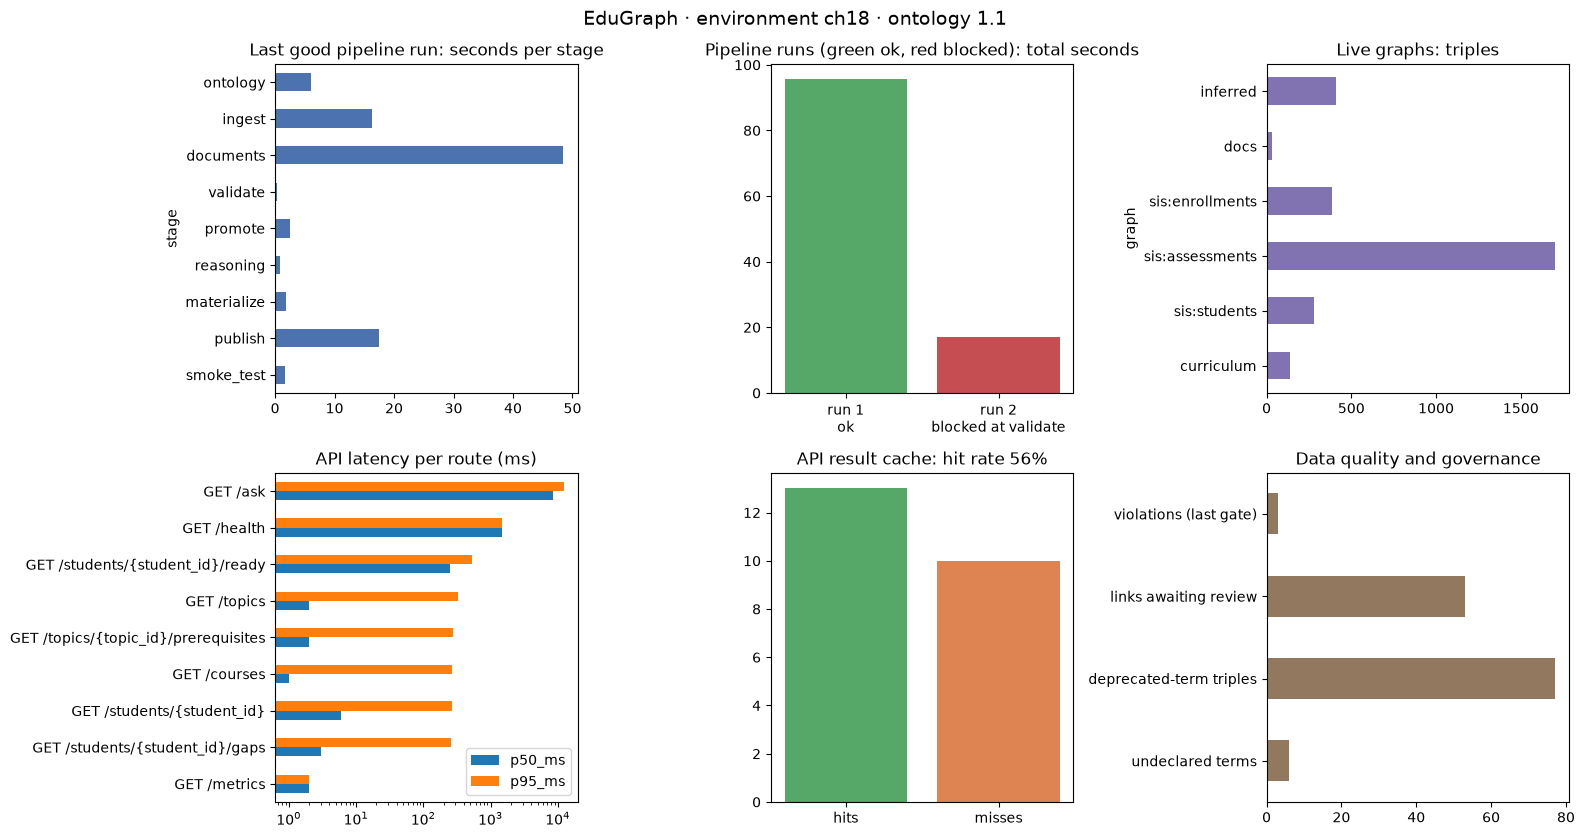

In [22]:
runs = history.groupby('run', sort=False).agg(started=('started', 'first'), status=('status', 'first'), seconds=('seconds', 'sum'))
last_ok = history[history.status == 'ok'].run.iloc[-1]
stages = history[history.run == last_ok].set_index('stage').seconds
sizes = sparql.run_query(conn, '''PREFIX edu: <http://example.org/edu#>
SELECT ?graph ?triples { ?run edu:graphSize [ edu:graph ?graph ; edu:triples ?triples ] } ''', graphs=ENV.metrics, run=URIRef(last_ok))
sizes['graph'] = sizes.graph.str.replace(ENV.prefix + ':', '', regex=False)
routes = pd.DataFrame(api.get('/metrics', headers=H).json()['routes']).T
routes = routes[routes.requests > 0].sort_values('p95_ms')
quality = {
    'violations (last gate)': int((report.results.severity == 'Violation').sum()),
    'links awaiting review': int(sparql.run_query(conn, 'PREFIX edu: <http://example.org/edu#> SELECT (COUNT(*) AS ?n) { ?l edu:status "review" }',
                                                  graphs=ENV.live('review')).n.iloc[0]),
    'deprecated-term triples': int(governance.deprecated_usage(conn, ENV.ontology, ENV.data_graphs)['data triples'].sum()),
    'undeclared terms': len(governance.undeclared_terms(conn, ENV.ontology, ENV.data_graphs + [ENV.live('review')])),
}
cache_stats = api.get('/metrics', headers=H).json()['cache']

fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))
fig.suptitle(f'EduGraph · environment {ENV.name} · ontology {run1["stages"].outcome.iloc[0]["version"]}', fontsize=14)
stages.plot.barh(ax=ax[0, 0], color='#4c72b0', title='Last good pipeline run: seconds per stage').invert_yaxis()
colors = ['#55a868' if s == 'ok' else '#c44e52' for s in runs.status]
ax[0, 1].bar(range(len(runs)), runs.seconds, color=colors)
ax[0, 1].set_xticks(range(len(runs)), [f"run {i + 1}\n{s}" for i, s in enumerate(runs.status)])
ax[0, 1].set_title('Pipeline runs (green ok, red blocked): total seconds')
sizes.set_index('graph').triples.plot.barh(ax=ax[0, 2], color='#8172b2', title='Live graphs: triples').invert_yaxis()
routes[['p50_ms', 'p95_ms']].astype(float).plot.barh(ax=ax[1, 0], title='API latency per route (ms)', logx=True)
ax[1, 1].bar(['hits', 'misses'], [cache_stats['hits'], cache_stats['misses']], color=['#55a868', '#dd8452'])
ax[1, 1].set_title(f"API result cache: hit rate {cache_stats['hit_rate']:.0%}")
pd.Series(quality).plot.barh(ax=ax[1, 2], color='#937860', title='Data quality and governance').invert_yaxis()
plt.tight_layout()
plt.show()

Charts need someone to look at them. **Alert rules** don't: each is a condition over the same numbers, with a severity. A scheduler evaluates them after every pipeline run and every few minutes for the API, and notifies the owner:

In [23]:
last_status = runs.status.iloc[-1]
slowest = routes.p95_ms.astype(float).idxmax()
ALERTS = [
    ('Last pipeline run blocked', last_status != 'ok', 'high', f'last run: {last_status}; live data is stale until fixed'),
    ('API server errors', routes.server_errors.sum() > 0, 'high', f'{int(routes.server_errors.sum())} server errors'),
    ('Slow route (p95 > 5 s)', routes.p95_ms.astype(float).max() > 5000, 'medium', f'{slowest}: {routes.p95_ms[slowest]} ms'),
    ('Review queue > 25 links', quality['links awaiting review'] > 25, 'low', f"{quality['links awaiting review']} links wait for a person"),
    ('Deprecated terms still in use', quality['deprecated-term triples'] > 0, 'info', f"{quality['deprecated-term triples']} triples; blocks release 2.0"),
    ('Undeclared vocabulary', quality['undeclared terms'] > 0, 'info', f"{quality['undeclared terms']} terms missing from the ontology"),
]
alerts = pd.DataFrame(ALERTS, columns=['alert', 'firing', 'severity', 'detail'])
alerts.insert(0, 'state', ['🔴' if f and sev in ('high', 'medium') else '🟡' if f else '🟢'
                           for f, sev in zip(alerts.firing, alerts.severity)])
alerts.drop(columns='firing')

,state,alert,severity,detail
0,🔴,Last pipeline run blocked,high,last run: blocked at validate; live data is stale until fixed
1,🟢,API server errors,high,0 server errors
2,🔴,Slow route (p95 > 5 s),medium,GET /ask: 12336 ms
3,🟡,Review queue > 25 links,low,53 links wait for a person
4,🟡,Deprecated terms still in use,info,77 triples; blocks release 2.0
5,🟡,Undeclared vocabulary,info,6 terms missing from the ontology


Read this like an on-call engineer:

- **Last pipeline run blocked** fires, correctly: the bad batch from 18.3 is still unfixed. The API serves the last good data meanwhile, which is exactly the point of the gate. It's **high** because every day it stays red, the data gets older.
- **Slow route** fires for `/ask`: LLM answers take seconds. Expected, but worth watching, and a reason to cache answers or use a faster model.
- The **info** alerts are tasks for the ontology owner, not emergencies.

Each alert should come with a **runbook** entry (18.8): what it means, and what to do.

## 18.8 Operations

### Backups

Chapter 14's logical backup, applied to everything an environment needs to be rebuilt: live data, ontology, shapes and the metrics history:

In [24]:
backup_root = Path(tempfile.mkdtemp(prefix='edugraph-backup-'))
graphs = [ENV.live(p) for p in ENV.PARTS] + [ENV.inferred, ENV.ontology, ENV.data_shapes, ENV.ontology_shapes, ENV.metrics]
folder = backup.export_graphs(graphs, backup_root)
manifest = pd.DataFrame(json.loads((folder / 'manifest.json').read_text(encoding='utf-8')))
manifest['graph'] = manifest.graph.str.replace(ENV.prefix + ':', '', regex=False)
print(f"{manifest.triples.sum()} triples in {len(manifest)} files, "
      f"{sum(f.stat().st_size for f in folder.glob('*.gz')) / 1024:.0f} KB compressed")
shutil.rmtree(backup_root)
manifest.set_index('graph').T

3724 triples in 11 files, 15 KB compressed


graph,curriculum,sis:students,sis:enrollments,sis:assessments,docs,review,inferred,ontology,shapes:data,shapes:ontology,metrics
file,00.ttl.gz,01.ttl.gz,02.ttl.gz,03.ttl.gz,04.ttl.gz,05.ttl.gz,06.ttl.gz,07.ttl.gz,08.ttl.gz,09.ttl.gz,10.ttl.gz
triples,141,280,385,1700,32,371,409,151,103,36,116


Kept in object storage, with dated folders and a retention policy, that's a restorable history. **Test the restore** regularly (into a separate environment): a backup nobody has restored is a hope, not a backup.

### Continuous integration

Every change to the ontology, shapes, mappings, queries or code runs the same checks. For GitHub Actions, for example:

```yaml
name: edugraph
on: [pull_request]
jobs:
  checks:
    runs-on: ubuntu-latest
    env:                                 # a separate test database; secrets from the repository settings
      STARDOG_ENDPOINT: ${{ secrets.STARDOG_TEST_ENDPOINT }}
      STARDOG_USERNAME: ${{ secrets.STARDOG_TEST_USER }}
      STARDOG_PASSWORD: ${{ secrets.STARDOG_TEST_PASSWORD }}
      STARDOG_DATABASE: edugraph_test
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with: { python-version: '3.12' }
      - run: pip install -r requirements.txt
      - run: python -m pytest tests -q                                  # queries, shapes, API, governance
      - run: python ops/edugraph_pipeline.py run --env ci-${{ github.run_id }}
      - if: always()
        run: python ops/edugraph_pipeline.py teardown --env ci-${{ github.run_id }}
```

`tests/test_governance.py` holds the release checks from 18.2, so a breaking ontology change without a major version fails the build. The pipeline run proves that the whole chain still works on real data, and its exit code fails the job when a gate blocks.

### Runbook

| Symptom | Likely cause | First steps |
|---|---|---|
| Pipeline blocked at `validate` | bad rows in a source export | read the report (focus, path, message); fix at the source; re-run. Live data is unaffected |
| Pipeline blocked at `ontology` | ontology change without labels, ranges or version | fix the ontology file; the governance shapes list what's missing |
| Pipeline blocked at `reasoning` | data contradicts the ontology (e.g. something both a Student and a Topic) | `kg.reasoning.explain_inconsistency(conn, schema)` shows the proof |
| API p95 up | new connections, a slow query, or reasoning on a hot path | `/metrics` per route; query plans and profiles (Ch 15); materialize or cache |
| API 5xx errors | Stardog unreachable, expired password, timeouts | `/health`; Stardog Cloud status; rotate the API user's password (Ch 14) |
| Answers from `/ask` look wrong | retrieval picked the wrong entities | log the returned `sources`; improve labels or add entities; check the facts query |
| Data "disappeared" | named-graph security switched on, or a wrong `graphs=` scope | permissions per role (Ch 14); the environment's graph names (18.1) |

### Production checklist

- **Environments**: dev / test / prod as separate databases (or at least separate graph prefixes), deployed by the same script.
- **Secrets** in a secret manager or CI secrets, never in notebooks or git. One least-privilege user per application; rotate passwords.
- **Ontology** in git with versions, a change log from `governance.diff`, and deprecation before removal.
- **Quality gates**: SHACL before promotion; consistency after; smoke tests as the application's user.
- **Observability**: pipeline runs recorded in the graph; API metrics scraped; alert rules with owners and runbooks.
- **Recovery**: scheduled logical backups (plus server backups on self-managed Stardog), tested restores.
- **Performance**: connection pools, materialized hot paths, caches with clear expiry, `query.timeout` (Ch 15).
- **Scale and availability**: a Stardog cluster where downtime is costly; virtual graphs or cache targets where copying isn't allowed.

## 18.9 Exercises

1. **Release 1.2.** Add the review vocabulary (`edu:TopicLink`, `edu:document`, `edu:role`, `edu:mention`, `edu:method`, `edu:status`) to `ontology/edugraph.ttl` with labels, comments and ranges. Bump the version, run `governance.diff` against 1.1 and `check_version`, then re-run the pipeline. `undeclared_terms` should come back empty.
2. **Finish the deprecation.** Rewrite the three queries from 18.3 to use `edu:Enrollment` instead of `edu:enrolledIn`, run the tests, and check with `deprecated_usage` that no query uses the term any more. What must change before release 2.0 can remove it?
3. **Cache invalidation.** Instead of a fixed expiry, make the API clear its cache when a new pipeline run is promoted. Hint: the API can check the newest `edu:PipelineRun` in the metrics graph (cheaply, at most every few seconds).
4. **Tenant isolation, enforced.** Create one role and API user per tenant from 18.6 with `read` only on the shared curriculum and its own SIS graphs. Switch on named-graph security briefly (as in Chapter 14) and show that the `GRAPH ?g` query from 18.6 no longer leaks. Restore the option afterwards.
5. **A new alert.** Record the API's `/metrics` in the metrics graph every time you run the load test (a small `edu:ApiSnapshot` resource), and add an alert that fires when p95 of any route doubles compared with the previous snapshot.
6. **Chat quality.** Write ten questions with expected answers (a gold set, as in Chapter 11) and measure how many `/ask` answers contain the right topics. Try other values for `k` and `margin`, and compare with the generic Chapter 16 instructions.

## 18.10 Clean up

This removes the environment (graphs, reasoning model, stored queries, API user and role), the tenant and lint graphs, and the API settings from this process:

In [25]:
CLEAN_UP = True

if CLEAN_UP:
    print(pipeline.teardown(conn, ENV))
    leftovers = sparql.run_query(conn, f'''SELECT DISTINCT ?g {{ GRAPH ?g {{ ?s ?p ?o }} FILTER(STRSTARTS(STR(?g), "{ENV.prefix}:")) }}''').g
    with client.transaction(conn):
        for g in leftovers:
            conn.clear(graph_uri=g)
    print(f'removed {len(leftovers)} more graphs (tenants, lint)')
    for k in [k for k in os.environ if k.startswith('EDUGRAPH_')]:
        del os.environ[k]
    reused.close()
    conn.close()

{'graphs': 18, 'stored queries': 9, 'model': 'EduGraph_ch18'}


removed 8 more graphs (tenants, lint)


## Summary

- A knowledge-graph application has the usual layers, plus **meaning, rules and provenance in the data itself**. Name everything from the **environment**, so deployments can live side by side and be removed cleanly.
- Treat the **ontology as code**: versions, a prior version to compare against, change classification (breaking / minor / patch), governance shapes, and deprecation before removal.
- A production **pipeline** loads into **staging**, validates everything with SHACL, and **promotes in one transaction**. A failed gate leaves the live data untouched and the bad batch in quarantine. Every run is recorded in the graph.
- **Performance** in practice: reuse connections, cache what may be a little old, materialize hot inferences, keep query-time reasoning for the rest. A cluster adds availability and read capacity, not faster writes.
- **Multi-tenancy** by graph scoping is a convention; isolation needs named-graph security or separate databases.
- **Monitoring** combines pipeline records, API metrics and quality figures into a dashboard and alert rules, each with a runbook entry.

## Where to go next

That's the end of the tutorial. You've gone from a first triple (Chapter 1) to a governed, monitored, LLM-enabled knowledge-graph system. Some directions from here:

- **Your own data**: pick one system of record and one document collection, and rebuild this chapter's pipeline for them.
- **Stardog documentation**: [docs.stardog.com](https://docs.stardog.com), especially clustering, cache targets and Voicebox, which this Cloud setup couldn't show.
- **Standards**: SHACL Advanced Features, SPARQL 1.2 and RDF 1.2 (quoted triples, the standard form of edge properties), and PROV-O.
- **The other tutorials** in this repository: `quick_start/` and `supply_chain/` (graph analytics with Spark).